# Descriptive spatio-temporal analytics of Chicago taxi demand

This notebook uses the **full processed dataset** to analyze start time, trip duration and distance, origin/destination, price, and idle time at multiple spatial and temporal resolutions. Gaussian Mixture Models are intentionally deferred to `02_02_descriptive_analytics_gmm.ipynb`.

## Method and interpretation constraints

- DuckDB scans the 13+ million trip Parquet lazily; only aggregated results enter pandas.
- Spatial comparison uses census tracts and H3 resolutions 7, 8, and 9. Approximate H3 diameters are reported below.
- Chicago's public taxi coordinates are privacy-protected area centroids, not exact pickup points. H3 resolution 9 therefore gives finer bins but **not** finer true positional accuracy.
- Temporal comparison uses 15-minute, 1-hour, 4-hour, and daily bins.
- `trip_seconds` is used for trip duration. The published timestamps are audited separately because they are rounded.
- Idle time is an estimate between consecutive records for the same anonymized taxi. Gaps outside 0–12 hours are treated as off-shift/missing-observation gaps rather than operational idle time.

In [1]:
from pathlib import Path

import duckdb
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from run_config import PATHS, PROJECT_ROOT

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

GOLD = PATHS.gold_taxi_trips.as_posix()
SILVER = PATHS.silver_taxi_trips.as_posix()
BRONZE = PATHS.bronze_taxi_trips.as_posix()
for path in (GOLD, SILVER, BRONZE):
    if not Path(path).exists():
        raise FileNotFoundError(path)

con = duckdb.connect()
con.execute("SET threads = 4")
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{GOLD}')")

## 1. Coverage and overall trip profile

In [2]:
coverage = con.sql("""
SELECT
    COUNT(*) AS trips,
    COUNT(DISTINCT taxi_id) AS taxis,
    MIN(trip_start_timestamp) AS first_trip,
    MAX(trip_start_timestamp) AS last_trip,
    COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
    ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(AVG(fare), 2) AS mean_fare,
    ROUND(MEDIAN(fare), 2) AS median_fare
FROM trips
""").df()
display(coverage)

,trips,taxis,first_trip,last_trip,active_days,mean_miles,median_miles,mean_minutes,median_minutes,mean_fare,median_fare
0,13387586,3313,2024-01-01,2026-05-01,852,7.15,3.91,21.06,16.05,22.08,15.25


## 2. Timestamp rounding and invalid ordering

We test all pipeline layers. Rounding can make a short trip's displayed start and end equal and can make the timestamp-derived duration differ from `trip_seconds` by several minutes. It should not, by itself, create the extreme negative intervals seen in corrupt raw records.

In [3]:
layer_paths = {"bronze": BRONZE, "silver": SILVER, "gold": GOLD}
audit_rows = []
for layer, path in layer_paths.items():
    row = con.execute(f"""
        SELECT
            COUNT(*) AS rows,
            COUNT(*) FILTER (WHERE trip_end_timestamp < trip_start_timestamp) AS end_before_start,
            COUNT(*) FILTER (WHERE trip_end_timestamp = trip_start_timestamp) AS equal_timestamps,
            COUNT(*) FILTER (WHERE trip_seconds IS NULL) AS missing_trip_seconds
        FROM read_parquet('{path}')
    """).fetchone()
    audit_rows.append((layer, *row))

timestamp_audit = pd.DataFrame(audit_rows, columns=[
    "layer", "rows", "end_before_start", "equal_timestamps", "missing_trip_seconds"
]).set_index("layer")
display(timestamp_audit)

minute_grid = con.sql("""
SELECT
    EXTRACT(minute FROM trip_start_timestamp)::INTEGER AS minute,
    COUNT(*) AS trips
FROM trips GROUP BY 1 ORDER BY 1
""").df()
display(minute_grid)

duration_agreement = con.sql("""
SELECT
    ROUND(AVG(ABS(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds)), 1) AS mean_absolute_error_seconds,
    MEDIAN(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds) AS median_error_seconds,
    QUANTILE_CONT(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds, [0.01, 0.99]) AS error_p01_p99_seconds
FROM trips
""").df()
display(duration_agreement)

,rows,end_before_start,equal_timestamps,missing_trip_seconds
layer,,,,
bronze,15406960,100,3796019,2936
silver,13387587,0,2597942,0
gold,13387586,0,2597942,0


,minute,trips
0,0,3363972
1,15,3326785
2,30,3327706
3,45,3369123


,mean_absolute_error_seconds,median_error_seconds,error_p01_p99_seconds
0,320.7,5.0,"[-766.0, 756.0]"


### Handling decision

The minute-frequency table demonstrates 15-minute timestamp quantization. In bronze, end-before-start records have missing `trip_seconds` and include differences of days or months; they are malformed records, not a normal rounding artifact. The existing silver filter requires plausible positive `trip_seconds` and therefore removes them. We consequently:

1. use `trip_seconds` for duration and speed-related analysis;
2. reject records with missing/non-positive/implausible `trip_seconds` (already done in silver);
3. reject `end < start` explicitly if processing raw data in the future;
4. retain equal rounded timestamps when `trip_seconds` is valid, because many genuine trips shorter than roughly 15 minutes collapse to the same published timestamp; and
5. treat timestamp-derived idle time as approximate, with a 0–12 hour operational window.

## 3. Demand and trip characteristics over time

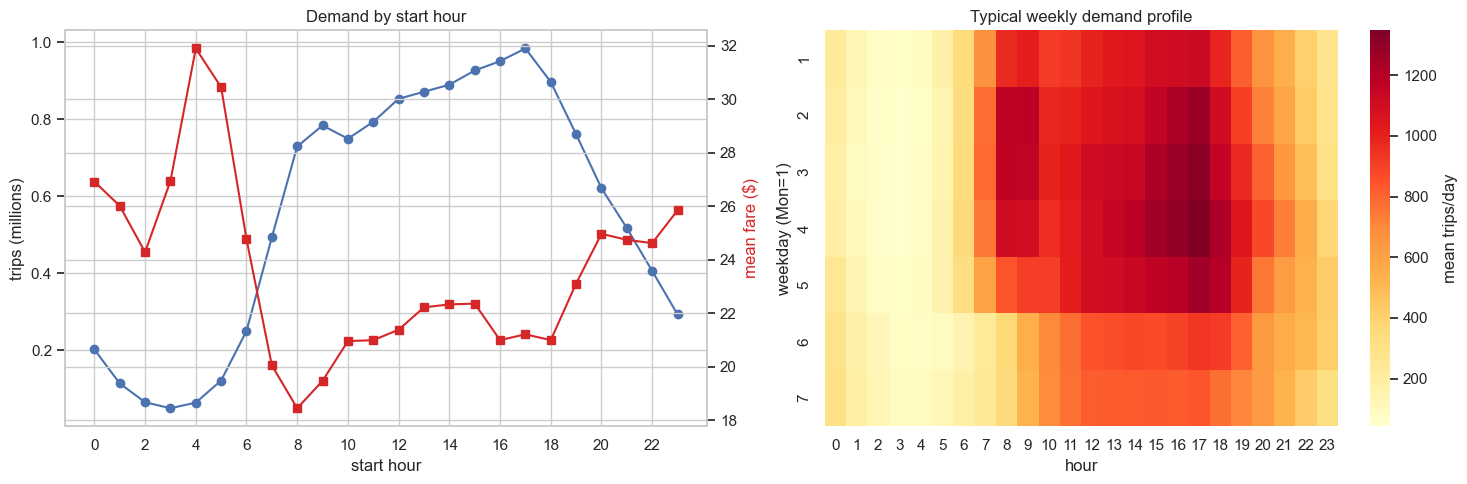

,hour,trips,mean_miles,mean_minutes,mean_fare,mean_total
0,0,202690,9.54,18.28,26.92,34.90
1,1,114728,9.11,17.48,26.01,33.51
2,2,65847,8.24,16.23,24.28,30.01
3,3,50202,9.19,16.52,26.94,31.22
4,4,64828,11.38,18.60,31.90,35.92
5,5,122144,11.00,20.11,30.45,35.43
6,6,250657,8.45,19.72,24.77,28.64
7,7,493416,6.22,18.93,20.05,23.39
8,8,729091,5.49,18.34,18.45,21.92
9,9,783600,6.14,18.37,19.47,23.44


In [4]:
hourly = con.sql("""
SELECT
    EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS hour,
    COUNT(*) AS trips,
    AVG(trip_miles) AS mean_miles,
    AVG(trip_seconds) / 60 AS mean_minutes,
    AVG(fare) AS mean_fare,
    AVG(trip_total) AS mean_total
FROM trips GROUP BY 1 ORDER BY 1
""").df()

weekly = con.sql("""
SELECT
    EXTRACT(isodow FROM trip_start_timestamp)::INTEGER AS weekday,
    EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS hour,
    COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE AS mean_trips_per_observed_day
FROM trips GROUP BY 1, 2 ORDER BY 1, 2
""").df()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(hourly.hour, hourly.trips / 1e6, marker="o", label="demand (million trips)")
axes[0].set(xlabel="start hour", ylabel="trips (millions)", title="Demand by start hour", xticks=range(0, 24, 2))
ax2 = axes[0].twinx()
ax2.plot(hourly.hour, hourly.mean_fare, color="tab:red", marker="s", label="mean fare")
ax2.set_ylabel("mean fare ($)", color="tab:red")
heat = weekly.pivot(index="weekday", columns="hour", values="mean_trips_per_observed_day")
sns.heatmap(heat, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "mean trips/day"})
axes[1].set(title="Typical weekly demand profile", xlabel="hour", ylabel="weekday (Mon=1)")
plt.tight_layout(); plt.show()
display(hourly.round(2))

## 4. Effect of temporal bin size

Short bins reveal peaks but have higher relative variability; long bins smooth local surges. The coefficient of variation (CV) makes variability comparable across bin sizes with different mean counts.

,bins,mean,median,p95,cv
bin_size,,,,,
15 minutes,81685,163.89,167.0,340.00,0.67
1 hour,20422,655.55,676.0,1347.95,0.66
4 hours,5107,2621.42,2430.0,5215.70,0.63
1 day,852,15713.13,16127.5,20958.90,0.23


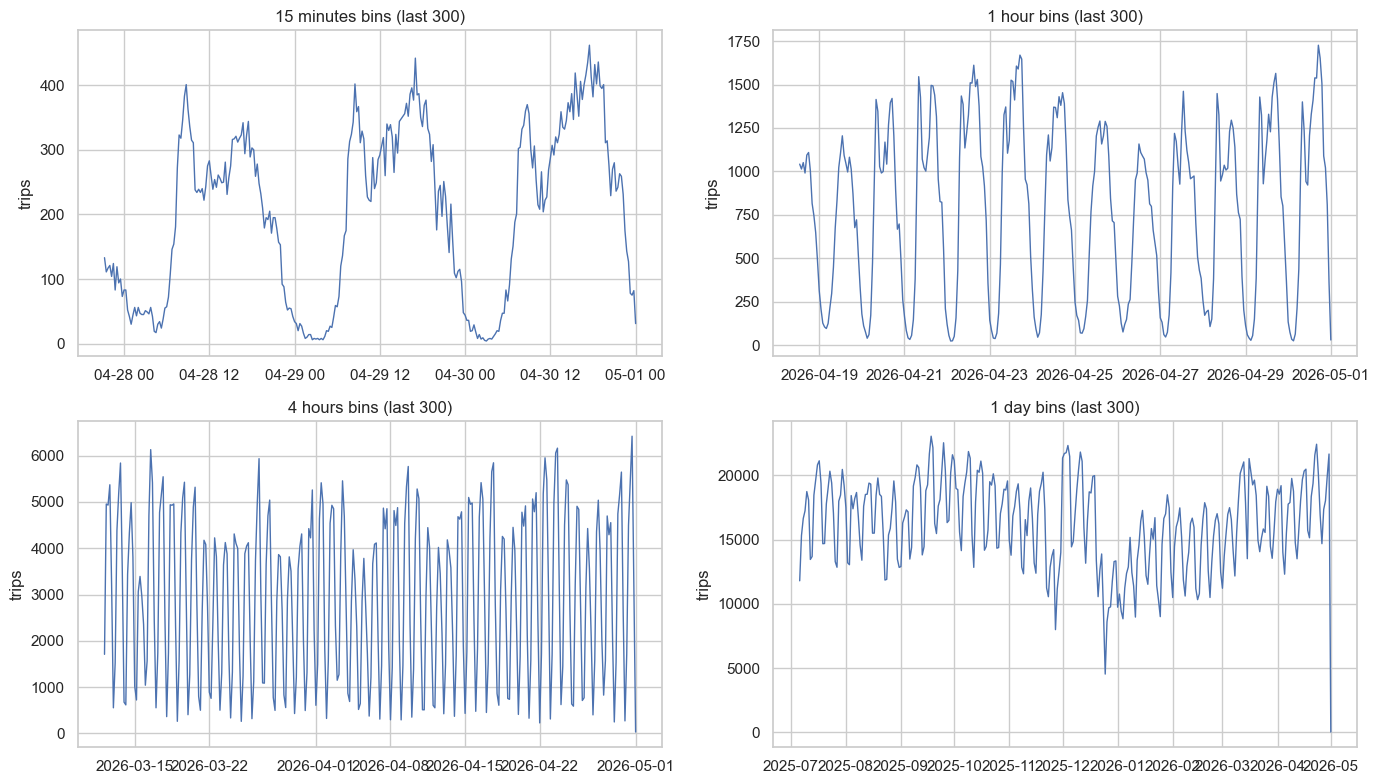

In [5]:
intervals = {"15 minutes": "15 minutes", "1 hour": "1 hour", "4 hours": "4 hours", "1 day": "1 day"}
bin_rows, bin_series = [], {}
for label, interval in intervals.items():
    values = con.execute(f"""
        SELECT TIME_BUCKET(INTERVAL '{interval}', trip_start_timestamp) AS time_bin, COUNT(*) AS trips
        FROM trips GROUP BY 1 ORDER BY 1
    """).df()
    bin_series[label] = values
    bin_rows.append({
        "bin_size": label, "bins": len(values), "mean": values.trips.mean(),
        "median": values.trips.median(), "p95": values.trips.quantile(.95),
        "cv": values.trips.std() / values.trips.mean()
    })
bin_summary = pd.DataFrame(bin_rows).set_index("bin_size")
display(bin_summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (label, values) in zip(axes.flat, bin_series.items()):
    sample = values.tail(min(len(values), 300))
    ax.plot(sample.time_bin, sample.trips, linewidth=1)
    ax.set_title(f"{label} bins (last {len(sample)})")
    ax.set_ylabel("trips")
plt.tight_layout(); plt.show()

## 5. Origin, destination, and spatial resolution

H3 7/8/9 comparisons use the published pickup centroid. Census tracts follow administrative/statistical boundaries; H3 cells are more uniform, reducing shape/area variation but not eliminating the Modifiable Areal Unit Problem (MAUP).

,all_trips,trips_with_dropoff_h3,missing_dropoff_h3,missing_pct
0,13387586,12447158,940428,7.02


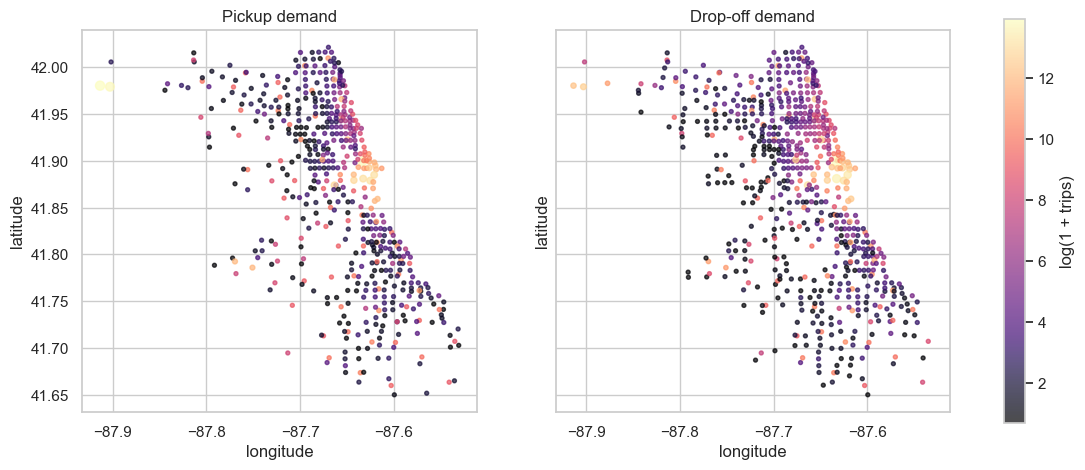

In [6]:
locations = con.sql("""
SELECT
    pickup_centroid_location AS location_id, pickup_centroid_latitude AS lat, pickup_centroid_longitude AS lon,
    pickup_census_tract AS census_tract, pickup_h3_cell AS h3_8, COUNT(*) AS trips,
    AVG(trip_miles) AS mean_miles, AVG(fare) AS mean_fare
FROM trips
WHERE pickup_centroid_latitude IS NOT NULL AND pickup_centroid_longitude IS NOT NULL
GROUP BY 1, 2, 3, 4, 5
""").df()
locations["h3_7"] = locations.h3_8.map(lambda cell: h3.cell_to_parent(cell, 7))
locations["h3_9"] = [h3.latlng_to_cell(lat, lon, 9) for lat, lon in zip(locations.lat, locations.lon)]

destinations = con.sql("""
SELECT dropoff_centroid_latitude AS lat, dropoff_centroid_longitude AS lon,
       dropoff_h3_cell AS h3_8, COUNT(*) AS trips
FROM trips WHERE dropoff_centroid_latitude IS NOT NULL AND dropoff_centroid_longitude IS NOT NULL
GROUP BY 1, 2, 3
""").df()
destinations["h3_7"] = destinations.h3_8.map(lambda cell: h3.cell_to_parent(cell, 7))
destinations["h3_9"] = [h3.latlng_to_cell(lat, lon, 9) for lat, lon in zip(destinations.lat, destinations.lon)]

dropoff_coverage = con.sql("""
SELECT COUNT(*) AS all_trips, COUNT(dropoff_h3_cell) AS trips_with_dropoff_h3,
       COUNT(*) - COUNT(dropoff_h3_cell) AS missing_dropoff_h3,
       ROUND(100.0 * (COUNT(*) - COUNT(dropoff_h3_cell)) / COUNT(*), 2) AS missing_pct
FROM trips
""").df()
display(dropoff_coverage)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, df, title in [(axes[0], locations, "Pickup demand"), (axes[1], destinations, "Drop-off demand")]:
    points = ax.scatter(df.lon, df.lat, c=np.log1p(df.trips), s=8 + 35 * df.trips / df.trips.max(), cmap="magma", alpha=.7)
    ax.set(title=title, xlabel="longitude", ylabel="latitude", aspect="equal")
fig.colorbar(points, ax=axes, label="log(1 + trips)", shrink=.75)
plt.show()

,units_with_demand,mean_trips_per_unit,median_trips_per_unit,cv_demand,top_10_unit_share
resolution,,,,,
H3 r7 (~2.81 km diameter),116,115410.224,11453.0,3.791,0.817
H3 r8 (~1.06 km diameter),376,35605.282,32.5,4.629,0.679
H3 r9 (~0.40 km diameter),532,25164.635,23.5,5.027,0.602
census tract,468,12927.571,15.0,6.522,0.757


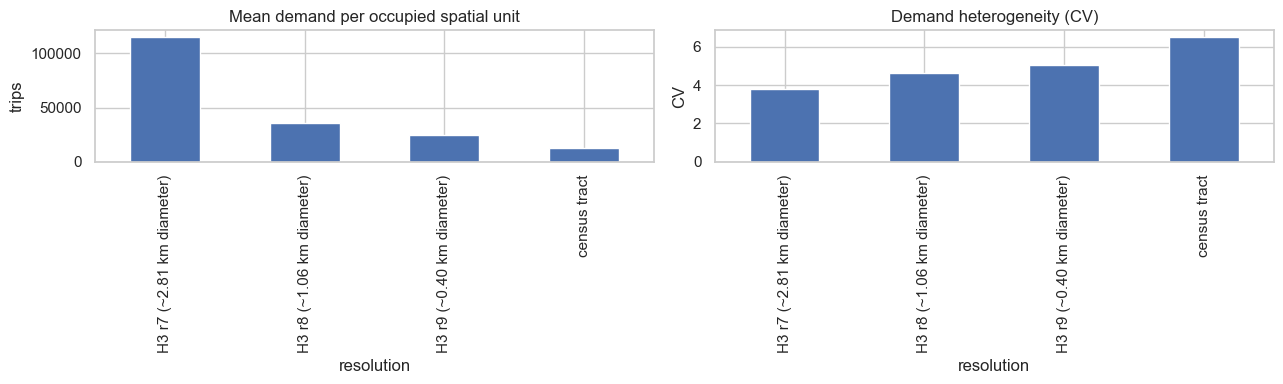

In [7]:
def resolution_metrics(frame, key, label):
    grouped = frame.groupby(key, dropna=True).agg(
        trips=("trips", "sum"),
        weighted_miles=("mean_miles", lambda x: np.nan),
    ).reset_index()
    counts = grouped.trips.sort_values(ascending=False)
    return {
        "resolution": label, "units_with_demand": len(counts),
        "mean_trips_per_unit": counts.mean(), "median_trips_per_unit": counts.median(),
        "cv_demand": counts.std() / counts.mean(),
        "top_10_unit_share": counts.head(10).sum() / counts.sum(),
    }

resolution_rows = []
for res in (7, 8, 9):
    edge = h3.average_hexagon_edge_length(res, unit="km")
    resolution_rows.append(resolution_metrics(locations, f"h3_{res}", f"H3 r{res} (~{2*edge:.2f} km diameter)"))
resolution_rows.append(resolution_metrics(locations, "census_tract", "census tract"))
resolution_summary = pd.DataFrame(resolution_rows).set_index("resolution")
display(resolution_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
resolution_summary.mean_trips_per_unit.plot.bar(ax=axes[0], title="Mean demand per occupied spatial unit")
resolution_summary.cv_demand.plot.bar(ax=axes[1], title="Demand heterogeneity (CV)")
axes[0].set_ylabel("trips"); axes[1].set_ylabel("CV")
plt.tight_layout(); plt.show()

### Pickup versus drop-off concentration across H3 resolutions

Trips without released drop-off coordinates remain in all non-destination analyses. They are excluded only from destination-specific aggregation because assigning an H3 cell would fabricate a location.

In [8]:
end_resolution_rows = []
for role, frame in [("pickup", locations), ("drop-off", destinations)]:
    for res in (7, 8, 9):
        counts = frame.groupby(f"h3_{res}", dropna=True).trips.sum().sort_values(ascending=False)
        end_resolution_rows.append({
            "role": role, "h3_resolution": res, "mapped_trips": counts.sum(),
            "occupied_cells": len(counts), "median_trips_per_cell": counts.median(),
            "top_10_cell_share": counts.head(10).sum() / counts.sum(),
            "demand_cv": counts.std() / counts.mean(),
        })
origin_destination_resolution = pd.DataFrame(end_resolution_rows).set_index(["role", "h3_resolution"])
display(origin_destination_resolution.round(3))

mapped_trips  occupied_cells  median_trips_per_cell  \
role     h3_resolution                                                        
pickup   7                  13387586             116                11453.0   
         8                  13387586             376                   32.5   
         9                  13387586             532                   23.5   
drop-off 7                  12447158             121                13175.0   
         8                  12447158             452                   43.0   
         9                  12447158             658                   39.5   

                        top_10_cell_share  demand_cv  
role     h3_resolution                                
pickup   7                          0.817      3.791  
         8                          0.679      4.629  
         9                          0.602      5.027  
drop-off 7                          0.742      3.947  
         8                          0.553      4.319  
         9                          0.461      4.435

### Joint spatial × temporal resolution sensitivity

The following comparison measures demand only in occupied unit–time bins. Fine spatial and temporal partitions create more sparse, volatile observations; aggregation pools them into more stable values. Zero-demand combinations are not materialized because the full Cartesian skeleton would be unnecessarily large.

,,units,occupied_unit_bins,mean_trips,median_trips,cv_demand,p95_trips
spatial_resolution,temporal_resolution,,,,,,
H3 r7,15 min,116,2072392,6.46,2.0,2.17,33.0
H3 r8,15 min,376,2619084,5.11,2.0,1.58,22.0
H3 r9,15 min,532,2878160,4.65,2.0,1.47,19.0
census tract,15 min,468,968427,6.25,4.0,1.23,22.0
H3 r7,1 hour,116,905044,14.79,3.0,2.94,69.0
H3 r8,1 hour,376,1144651,11.70,3.0,2.18,61.0
H3 r9,1 hour,532,1251512,10.70,3.0,2.03,49.0
census tract,1 hour,468,387698,15.61,6.0,1.65,64.0
H3 r7,4 hours,116,323074,41.44,6.0,3.46,178.0


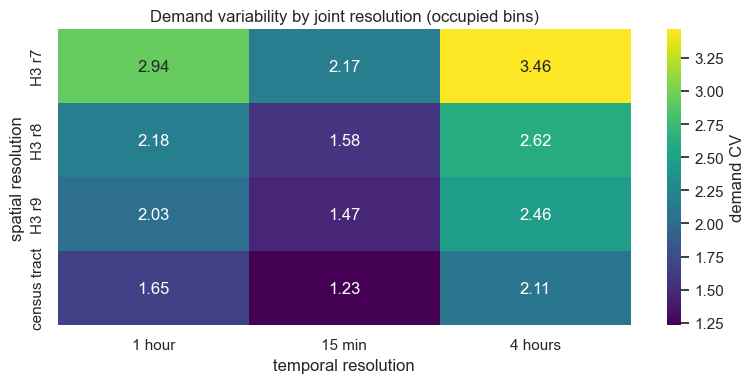

In [9]:
location_resolution_map = locations[["location_id", "h3_7", "h3_8", "h3_9"]].drop_duplicates()
con.register("location_resolution_map", location_resolution_map)
spatial_units = {
    "H3 r7": "m.h3_7", "H3 r8": "m.h3_8", "H3 r9": "m.h3_9",
    "census tract": "CAST(t.pickup_census_tract AS VARCHAR)",
}
joint_rows = []
for time_label, interval in {"15 min": "15 minutes", "1 hour": "1 hour", "4 hours": "4 hours"}.items():
    for spatial_label, unit_expr in spatial_units.items():
        result = con.execute(f"""
            WITH counts AS (
                SELECT TIME_BUCKET(INTERVAL '{interval}', t.trip_start_timestamp) AS time_bin,
                       {unit_expr} AS spatial_unit, COUNT(*) AS trips
                FROM trips t
                LEFT JOIN location_resolution_map m ON t.pickup_centroid_location = m.location_id
                WHERE {unit_expr} IS NOT NULL
                GROUP BY 1, 2
            )
            SELECT COUNT(DISTINCT spatial_unit), COUNT(*), AVG(trips), MEDIAN(trips),
                   STDDEV_SAMP(trips) / AVG(trips), QUANTILE_CONT(trips, .95)
            FROM counts
        """).fetchone()
        joint_rows.append((spatial_label, time_label, *result))

joint_resolution = pd.DataFrame(joint_rows, columns=[
    "spatial_resolution", "temporal_resolution", "units", "occupied_unit_bins",
    "mean_trips", "median_trips", "cv_demand", "p95_trips"
]).set_index(["spatial_resolution", "temporal_resolution"])
display(joint_resolution.round(2))

cv_matrix = joint_resolution.cv_demand.unstack("temporal_resolution")
plt.figure(figsize=(8, 4))
sns.heatmap(cv_matrix, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "demand CV"})
plt.title("Demand variability by joint resolution (occupied bins)")
plt.xlabel("temporal resolution"); plt.ylabel("spatial resolution"); plt.tight_layout(); plt.show()

### Dominant origin–destination flows

In [10]:
top_flows = con.sql("""
SELECT
    pickup_community_area AS origin_area, dropoff_community_area AS destination_area,
    COUNT(*) AS trips, ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes, ROUND(AVG(fare), 2) AS mean_fare
FROM trips
WHERE pickup_community_area IS NOT NULL AND dropoff_community_area IS NOT NULL
GROUP BY 1, 2 ORDER BY trips DESC LIMIT 20
""").df()
display(top_flows)

,origin_area,destination_area,trips,mean_miles,mean_minutes,mean_fare
0,8,8,923486,1.00,7.49,7.46
1,32,8,684869,1.38,9.64,8.40
2,8,32,651549,1.38,9.64,8.59
3,76,8,592916,17.41,43.83,45.69
4,32,32,447820,0.94,6.97,7.11
5,28,8,421868,1.84,12.24,9.73
6,8,28,398223,2.03,12.98,10.41
7,76,32,378722,18.06,44.83,47.27
8,28,32,366594,1.16,8.05,7.45
9,32,28,352919,1.40,8.96,8.21


## 6. Approximate idle time between trips

For each taxi, the prior published end timestamp is compared with the next start. Because both are rounded to 15 minutes, individual gaps have roughly ±15-minute measurement uncertainty. Negative gaps are not automatically data errors here: adjacent short trips can overlap after independent rounding. We retain only gaps from 0 to 12 hours and report robust medians as well as means.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,hour,usable_gaps,mean_idle_minutes,median_idle_minutes,p90_idle_minutes
0,0,193923,84.3,45.0,195.0
1,1,110242,81.5,45.0,195.0
2,2,62648,83.3,45.0,195.0
3,3,44573,105.5,45.0,270.0
4,4,51002,170.4,60.0,570.0
5,5,85562,242.2,90.0,645.0
6,6,175876,206.5,45.0,660.0
7,7,370693,128.3,15.0,615.0
8,8,587160,82.7,15.0,240.0
9,9,643985,67.4,15.0,135.0


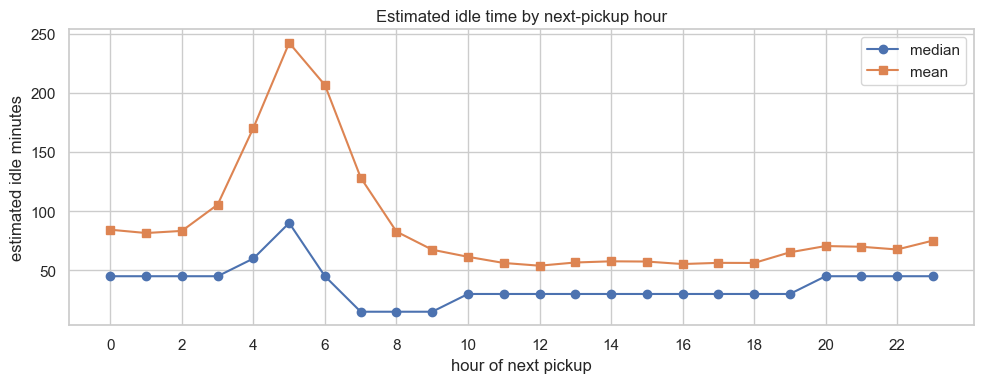

In [11]:
idle_by_hour = con.sql("""
WITH ordered AS (
    SELECT *, LAG(trip_end_timestamp) OVER (PARTITION BY taxi_id ORDER BY trip_start_timestamp, trip_id) AS previous_end
    FROM trips
), gaps AS (
    SELECT EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS hour,
           EPOCH(trip_start_timestamp - previous_end) / 60 AS idle_minutes
    FROM ordered WHERE previous_end IS NOT NULL
)
SELECT hour, COUNT(*) AS usable_gaps, ROUND(AVG(idle_minutes), 1) AS mean_idle_minutes,
       ROUND(MEDIAN(idle_minutes), 1) AS median_idle_minutes,
       ROUND(QUANTILE_CONT(idle_minutes, .9), 1) AS p90_idle_minutes
FROM gaps WHERE idle_minutes BETWEEN 0 AND 720
GROUP BY 1 ORDER BY 1
""").df()
display(idle_by_hour)

plt.figure(figsize=(10, 4))
plt.plot(idle_by_hour.hour, idle_by_hour.median_idle_minutes, marker="o", label="median")
plt.plot(idle_by_hour.hour, idle_by_hour.mean_idle_minutes, marker="s", label="mean")
plt.xticks(range(0, 24, 2)); plt.xlabel("hour of next pickup"); plt.ylabel("estimated idle minutes")
plt.title("Estimated idle time by next-pickup hour"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Comparison across 2024, 2025, and 2026

Raw annual totals are not directly comparable because 2026 is only observed through early May. We therefore report coverage and demand per active day, compare like-for-like January–April periods, and measure differences between normalized temporal and spatial demand distributions. Jensen–Shannon distance is bounded between 0 (identical distributions) and 1 (completely separated distributions).

In [12]:
year_summary = con.sql("""
SELECT
    YEAR(trip_start_timestamp)::INTEGER AS year,
    MIN(CAST(trip_start_timestamp AS DATE)) AS first_date,
    MAX(CAST(trip_start_timestamp AS DATE)) AS last_date,
    COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
    COUNT(*) AS trips,
    ROUND(COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE, 1) AS trips_per_active_day,
    ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(AVG(fare), 2) AS mean_fare,
    ROUND(AVG(trip_total), 2) AS mean_total
FROM trips GROUP BY 1 ORDER BY 1
""").df()
display(year_summary)

like_for_like = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year, COUNT(*) AS jan_apr_trips,
       COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
       ROUND(COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE, 1) AS trips_per_active_day,
       ROUND(AVG(trip_miles), 2) AS mean_miles,
       ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
       ROUND(AVG(fare), 2) AS mean_fare, ROUND(AVG(trip_total), 2) AS mean_total
FROM trips
WHERE MONTH(trip_start_timestamp) BETWEEN 1 AND 4
GROUP BY 1 ORDER BY 1
""").df()
display(like_for_like)

,year,first_date,last_date,active_days,trips,trips_per_active_day,mean_miles,median_miles,mean_minutes,median_minutes,mean_fare,mean_total
0,2024,2024-01-01,2024-12-31,366,5513719,15064.8,7.65,4.89,22.32,17.70,23.19,28.72
1,2025,2025-01-01,2025-12-31,365,6005191,16452.6,7.01,3.76,20.77,15.87,21.75,26.59
2,2026,2026-01-01,2026-05-01,121,1868676,15443.6,6.16,2.72,18.33,13.57,19.88,24.25


,year,jan_apr_trips,active_days,trips_per_active_day,mean_miles,mean_minutes,mean_fare,mean_total
0,2024,1645380,121,13598.2,7.45,20.91,22.82,28.20
1,2025,1778001,120,14816.7,7.27,20.22,21.94,26.81
2,2026,1868645,120,15572.0,6.16,18.33,19.88,24.25


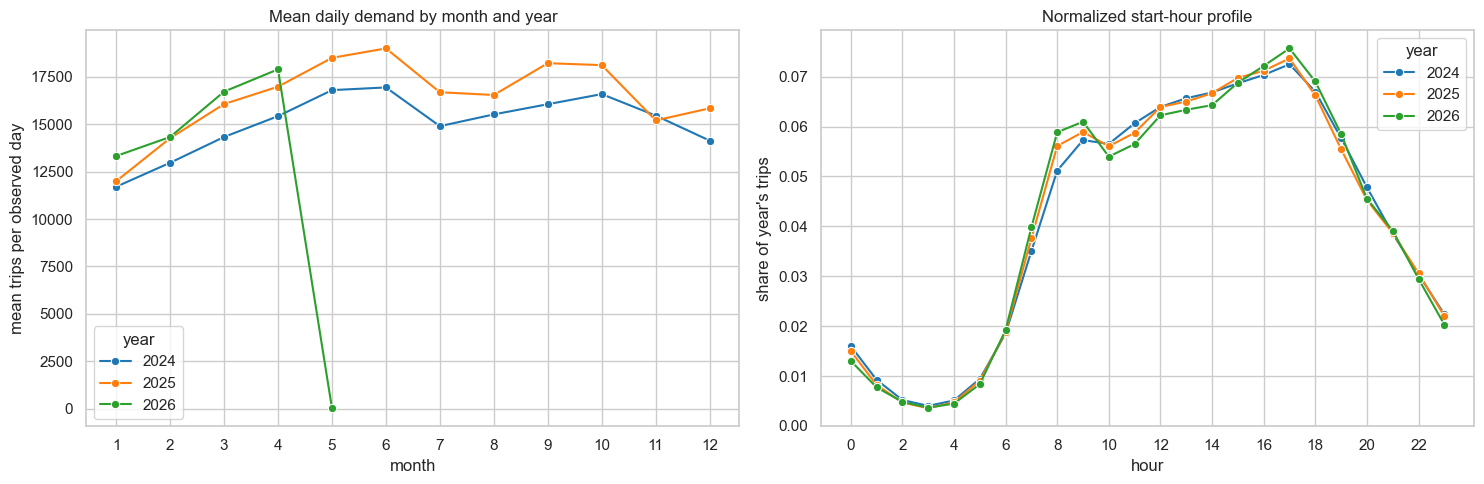

In [13]:
monthly_year = con.sql("""
WITH daily AS (
    SELECT YEAR(trip_start_timestamp)::INTEGER AS year, MONTH(trip_start_timestamp)::INTEGER AS month,
           CAST(trip_start_timestamp AS DATE) AS date, COUNT(*) AS trips
    FROM trips GROUP BY 1, 2, 3
)
SELECT year, month, AVG(trips) AS mean_daily_trips FROM daily GROUP BY 1, 2 ORDER BY 1, 2
""").df()
hour_year = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year,
       EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS hour, COUNT(*) AS trips
FROM trips GROUP BY 1, 2 ORDER BY 1, 2
""").df()
hour_year["share"] = hour_year.trips / hour_year.groupby("year").trips.transform("sum")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly_year, x="month", y="mean_daily_trips", hue="year", marker="o", palette="tab10", ax=axes[0])
axes[0].set(title="Mean daily demand by month and year", xlabel="month", ylabel="mean trips per observed day", xticks=range(1, 13))
sns.lineplot(data=hour_year, x="hour", y="share", hue="year", marker="o", palette="tab10", ax=axes[1])
axes[1].set(title="Normalized start-hour profile", xlabel="hour", ylabel="share of year's trips", xticks=range(0, 24, 2))
plt.tight_layout(); plt.show()

In [14]:
def jensen_shannon_distance(p, q):
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return np.sqrt(0.5 * kl(p, m) + 0.5 * kl(q, m))

hour_matrix = hour_year.pivot(index="hour", columns="year", values="trips").fillna(0)
spatial_year = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year, pickup_h3_cell AS h3_cell, COUNT(*) AS trips
FROM trips WHERE pickup_h3_cell IS NOT NULL GROUP BY 1, 2
""").df()
spatial_matrix = spatial_year.pivot(index="h3_cell", columns="year", values="trips").fillna(0)

distance_rows = []
for first, second in [(2024, 2025), (2024, 2026), (2025, 2026)]:
    distance_rows.append({
        "comparison": f"{first} vs {second}",
        "hourly_profile_JS_distance": jensen_shannon_distance(hour_matrix[first], hour_matrix[second]),
        "spatial_H3_r8_JS_distance": jensen_shannon_distance(spatial_matrix[first], spatial_matrix[second]),
    })
profile_distances = pd.DataFrame(distance_rows).set_index("comparison")
display(profile_distances.round(4))

relative_metrics = year_summary.set_index("year")[["trips_per_active_day", "mean_miles", "mean_minutes", "mean_fare", "mean_total"]]
relative_change = 100 * relative_metrics.pct_change()
display(relative_change.round(2).rename_axis("year vs previous year (%)"))

,hourly_profile_JS_distance,spatial_H3_r8_JS_distance
comparison,,
2024 vs 2025,0.0158,0.0641
2024 vs 2026,0.0279,0.1223
2025 vs 2026,0.0171,0.0684


,trips_per_active_day,mean_miles,mean_minutes,mean_fare,mean_total
year vs previous year (%),,,,,
2024,NaN,NaN,NaN,NaN,NaN
2025,9.21,-8.37,-6.94,-6.21,-7.42
2026,-6.13,-12.13,-11.75,-8.60,-8.80


### Modeling recommendation

Do **not** select a training year from raw totals: 2026 is partial and seasonally truncated. Compare the normalized tables and Jensen–Shannon distances above. Even when hour-of-day shapes are similar, changes in demand level, fare, trip characteristics, or spatial shares represent useful concept drift that a deployment model should learn and that validation should test.

Recommended design:

- train on 2024 plus the earlier portion of 2025;
- tune/validate on a later contiguous 2025 block;
- keep 2026 as an untouched forward-in-time holdout; and
- include calendar, weather, spatial-unit, and year/trend features rather than letting the model memorize timestamps.

If computational limits force a single year, 2025 is the best candidate because it is the most recent complete year. That is a compromise: it removes seasonal coverage concerns but prevents a robust test of year-to-year stability and discards valuable training observations. A useful sensitivity experiment is to compare a 2025-only model with the recommended 2024–2025 model on the identical 2026 holdout.

## 8. Interpretation and possible reasons

- **Time of day:** commuting, airport schedules, nightlife, weather, and major events can create morning/evening or late-night demand peaks. Fares and distances may rise when airport and cross-city journeys form a larger share of demand.
- **Temporal aggregation:** 15-minute bins expose short surges but are noisy and affected by timestamp quantization. Four-hour/daily bins are stable but hide peak timing. Hourly bins are a defensible compromise for these data.
- **Spatial aggregation and MAUP:** coarse H3 cells pool nearby hot and cold locations, increasing counts and smoothing extremes. Fine H3 cells reveal concentration but can exaggerate instability. Census tracts vary in size and align with population boundaries; H3 cells are uniform but do not align with neighborhoods or transport infrastructure.
- **Airport and downtown effects:** dense employment, hotels, rail stations, entertainment, and airports plausibly explain concentrated pickup/drop-off demand and longer or more expensive dominant flows.
- **Privacy centroids:** repeated public centroids create artificial point clusters. H3 r9 should be interpreted as partitioning released centroids, not locating exact street-level hot spots.
- **Idle time:** high-demand central/airport zones can shorten search time, while repositioning, driver breaks, shift boundaries, missing trips, and 15-minute timestamp rounding can lengthen or distort observed gaps. It is an operational proxy, not direct vacant-taxi telemetry.
- **Data-quality rule:** use `trip_seconds` for duration, retain equal timestamps when `trip_seconds` is valid, and exclude missing/implausible duration or end-before-start raw records. The current silver/gold data already exclude all 100 raw end-before-start cases.

The next notebook performs the separate GMM-based spatial hot-spot analysis.

In [15]:
con.close()